In [2]:
from tensorflow.keras.models import load_model

model = load_model("../models/resnet50_final.keras")

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

img_size = (160,160)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_gen.flow_from_directory(
    "../data/test",
    target_size=img_size,
    batch_size=8,
    class_mode="categorical",
    shuffle=False
)

Found 3507 images belonging to 10 classes.


In [4]:
loss, acc = model.evaluate(test_data)
print("Test accuracy:", acc)

439/439 ━━━━━━━━━━━━━━━━━━━━ 58s 126ms/step - accuracy: 0.8600 - loss: 0.5047
Test accuracy: 0.8599942922592163


In [5]:
from tensorflow.keras.models import load_model
model = load_model("../models/resnet50_final.keras")

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_gen.flow_from_directory(
    "../data/test",
    target_size=(160,160),
    batch_size=8,
    class_mode="categorical",
    shuffle=False
)

Found 3507 images belonging to 10 classes.


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix

pred = model.predict(test_data)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred)

439/439 ━━━━━━━━━━━━━━━━━━━━ 162s 364ms/step


In [12]:
import numpy as np

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(test_data.class_indices.keys(), class_acc):
    print(cls, round(acc,3))

Chinee apple 0.686
Lantana 0.808
Negative 0.911
Parkinsonia 0.918
Parthenium 0.844
Prickly acacia 0.869
Rubber vine 0.817
Siam weed 0.847
Snake weed 0.662


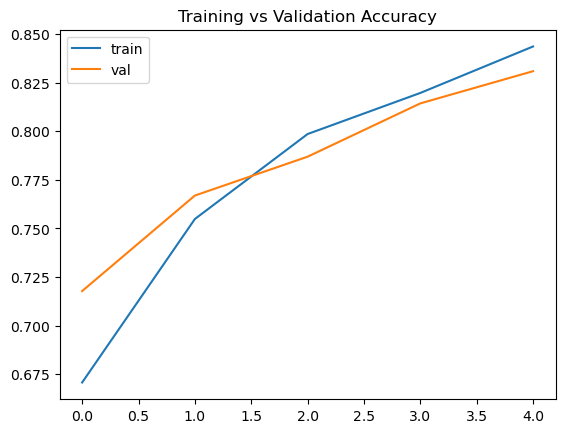

In [13]:
import pickle
import matplotlib.pyplot as plt

with open("../results/history.pkl","rb") as f:
    hist = pickle.load(f)

plt.plot(hist["accuracy"], label="train")
plt.plot(hist["val_accuracy"], label="val")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


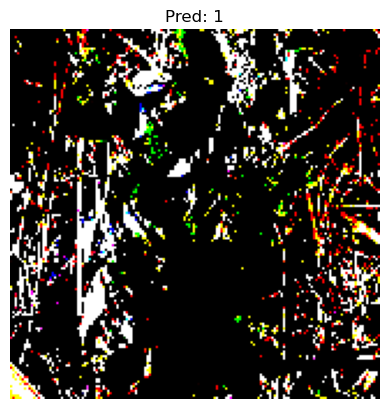

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


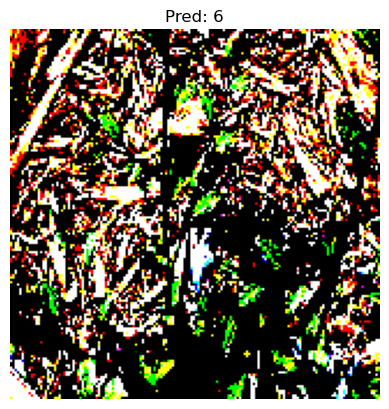

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


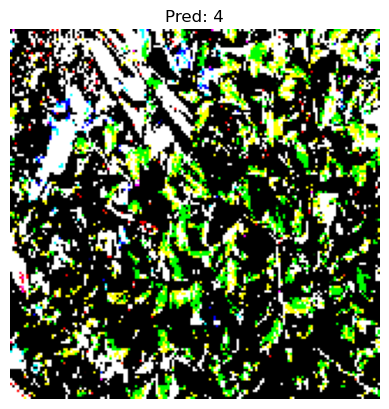

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


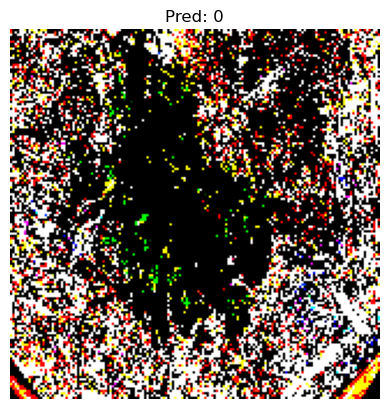

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


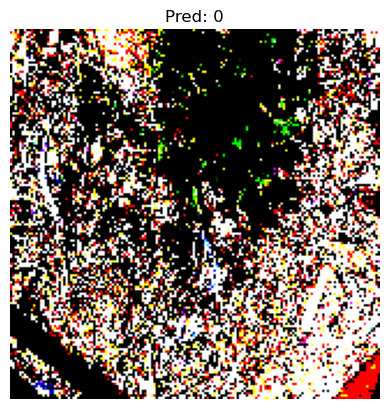

In [14]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(test_data)
preds = model.predict(images)

for i in range(5):
    plt.imshow(images[i])
    plt.title(f"Pred: {np.argmax(preds[i])}")
    plt.axis("off")
    plt.show()

439/439 ━━━━━━━━━━━━━━━━━━━━ 132s 301ms/step


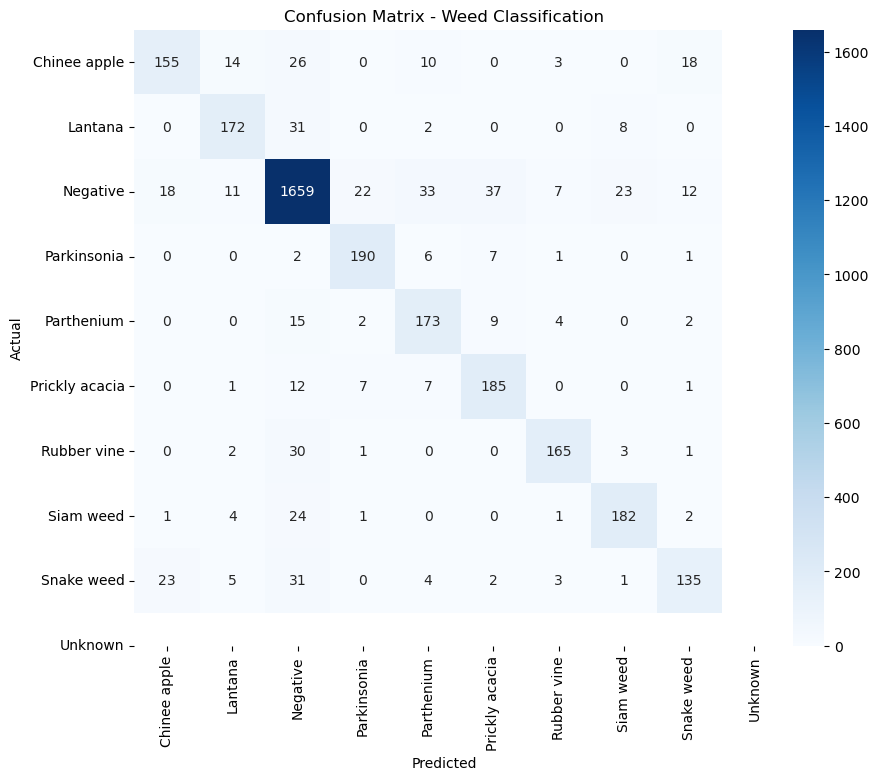

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# predict on test set
pred = model.predict(test_data)
y_pred = np.argmax(pred, axis=1)

# true labels
y_true = test_data.classes

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# class names
class_names = list(test_data.class_indices.keys())

# plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Weed Classification")
plt.show()

439/439 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step


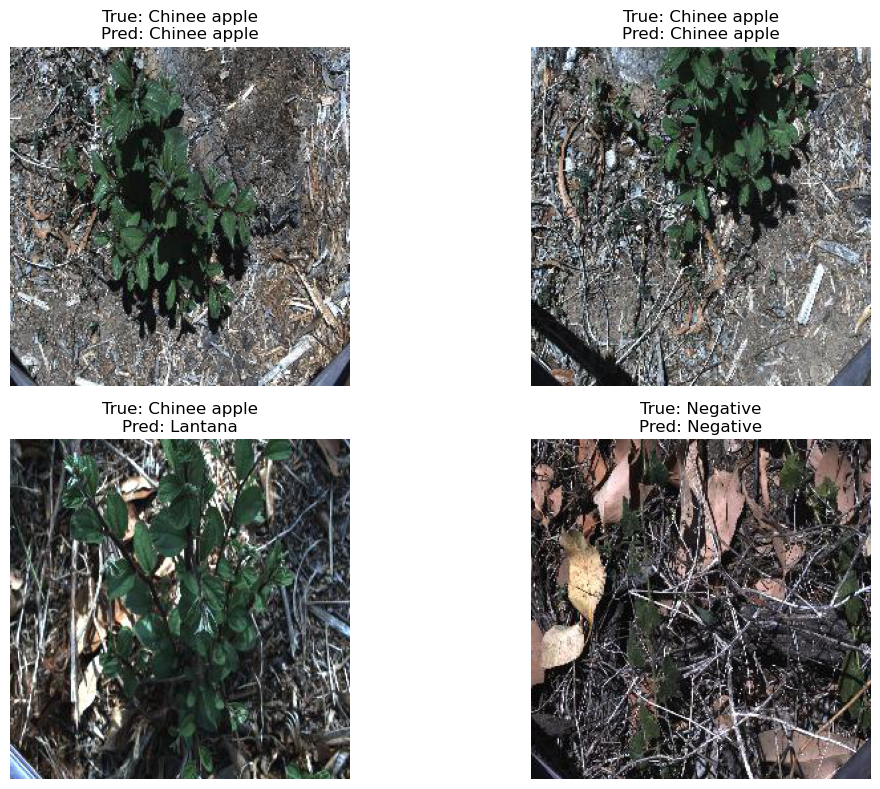

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Reset generator
test_data.reset()

pred = model.predict(test_data)
y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())
file_paths = test_data.filepaths

correct_imgs = []
wrong_imgs = []
negative_img = None

for i in range(len(y_true)):
    if y_pred[i] == y_true[i] and len(correct_imgs) < 2:
        correct_imgs.append(i)

    if y_pred[i] != y_true[i] and len(wrong_imgs) < 1:
        wrong_imgs.append(i)

    if class_names[y_true[i]] == "Negative" and negative_img is None:
        negative_img = i

    if len(correct_imgs) == 2 and len(wrong_imgs) == 1 and negative_img is not None:
        break

selected_indices = correct_imgs + wrong_imgs + [negative_img]

plt.figure(figsize=(12,8))

for idx, img_index in enumerate(selected_indices):
    img = plt.imread(file_paths[img_index])
    true_label = class_names[y_true[img_index]]
    pred_label = class_names[y_pred[img_index]]

    plt.subplot(2,2,idx+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("../results/sample_predictions.png", dpi=300)
plt.show()